In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/processed/macro_data.csv", parse_dates=['Date'], index_col='Date')
df = df.sort_index()
print(df.head())


            GDP  Inflation  Unemployment  CurrentAccount  Exports  Imports
Date                                                                      
1997-01-01  1.6        2.4           7.3             0.3    32600    32723
1997-04-01  1.1        2.1           7.2            -0.4    32173    33777
1997-07-01  0.9        2.3           6.8            -0.1    32015    33076
1997-10-01  1.5        2.1           6.5            -0.4    32527    34036
1998-01-01  0.7        1.8           6.4            -1.2    33106    33946


In [2]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series)
    print(f"{name} — ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}")
    if result[1] <= 0.05:
        print("Stationary")
    else:
        print("Not Stationary")
    print("-" * 50)

# Run test on all columns
for col in df.columns:
    adf_test(df[col], col)


GDP — ADF Statistic: -4.4069, p-value: 0.0003
Stationary
--------------------------------------------------
Inflation — ADF Statistic: -1.7509, p-value: 0.4051
Not Stationary
--------------------------------------------------
Unemployment — ADF Statistic: -2.7670, p-value: 0.0631
Not Stationary
--------------------------------------------------
CurrentAccount — ADF Statistic: -2.5036, p-value: 0.1146
Not Stationary
--------------------------------------------------
Exports — ADF Statistic: -0.6828, p-value: 0.8512
Not Stationary
--------------------------------------------------
Imports — ADF Statistic: -0.0205, p-value: 0.9568
Not Stationary
--------------------------------------------------


In [3]:
df_diff = df.copy()
to_diff = ['Inflation', 'Unemployment', 'CurrentAccount', 'Exports', 'Imports']
df_diff[to_diff] = df_diff[to_diff].diff()

# Drop NaNs caused by differencing
df_diff.dropna(inplace=True)

In [4]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"{name} — ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}")
    if result[1] <= 0.05:
        print("Stationary")
    else:
        print("Not stationary")
    print('-'*50)

# Run ADF test on each column after differencing
for col in df_diff.columns:
    adf_test(df_diff[col], col)


GDP — ADF Statistic: -4.8639, p-value: 0.0000
Stationary
--------------------------------------------------
Inflation — ADF Statistic: -4.9187, p-value: 0.0000
Stationary
--------------------------------------------------
Unemployment — ADF Statistic: -3.8626, p-value: 0.0023
Stationary
--------------------------------------------------
CurrentAccount — ADF Statistic: -5.5933, p-value: 0.0000
Stationary
--------------------------------------------------
Exports — ADF Statistic: -7.3780, p-value: 0.0000
Stationary
--------------------------------------------------
Imports — ADF Statistic: -6.0863, p-value: 0.0000
Stationary
--------------------------------------------------


In [5]:
# Chronological split
train_size = int(len(df_diff) * 0.7)
train = df_diff.iloc[:train_size]
test = df_diff.iloc[train_size:]


In [6]:
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

max_lag = 8
results = []

# Grid search algorithm
for lag in range(1, max_lag + 1):
    try:
        model = VAR(train)
        model_fitted = model.fit(lag)
        forecast = model_fitted.forecast(train.values[-lag:], steps=len(test))
        forecast_df = pd.DataFrame(forecast, index=test.index, columns=train.columns)

        actual = test['GDP']
        predicted = forecast_df['GDP']

        mae = mean_absolute_error(actual, predicted)
        rmse = np.sqrt(mean_squared_error(actual, predicted))
        r2 = r2_score(actual, predicted)

        results.append({'Lag': lag, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    except:
        continue

results_df = pd.DataFrame(results).sort_values('RMSE')
print("Grid Search Results:")
print(results_df)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be use

Grid Search Results:
   Lag        MAE       RMSE            R2
1    2   0.256243   0.299136     -0.516190
0    1   0.266367   0.307940     -0.606753
2    3   0.282156   0.352454     -1.104855
4    5   0.320292   0.405000     -1.779244
3    4   0.372633   0.519992     -3.581528
5    6   1.415873   1.661736    -45.788676
6    7   2.664703   3.274786   -180.711517
7    8  36.749652  59.738167 -60466.268240


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


In [7]:
best_lag = 2  # from grid search
model = VAR(train)
model_fitted = model.fit(best_lag)
print(model_fitted.summary())


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 30, Apr, 2025
Time:                     15:56:52
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                    24.9531
Nobs:                     61.0000    HQIC:                   23.3118
Log likelihood:          -1120.08    FPE:                4.80894e+09
AIC:                      22.2539    Det(Omega_mle):     1.50882e+09
--------------------------------------------------------------------
Results for equation GDP
                       coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------
const                     0.094903         0.104323            0.910           0.363
L1.GDP                    0.667136         0.151208            4.412           0.000
L1.Inflation             -0.018495         0.1

In [8]:
forecast = model_fitted.forecast(train.values[-best_lag:], steps=len(test))
forecast_df = pd.DataFrame(forecast, index=test.index, columns=train.columns)

# Evaluate GDP
actual = test['GDP']
predicted = forecast_df['GDP']

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
r2 = r2_score(actual, predicted)

print(f"GDP Forecast Evaluation:\nMAE: {mae:.4f}\nRMSE: {rmse:.4f}\nR²: {r2:.4f}")


GDP Forecast Evaluation:
MAE: 0.2562
RMSE: 0.2991
R²: -0.5162


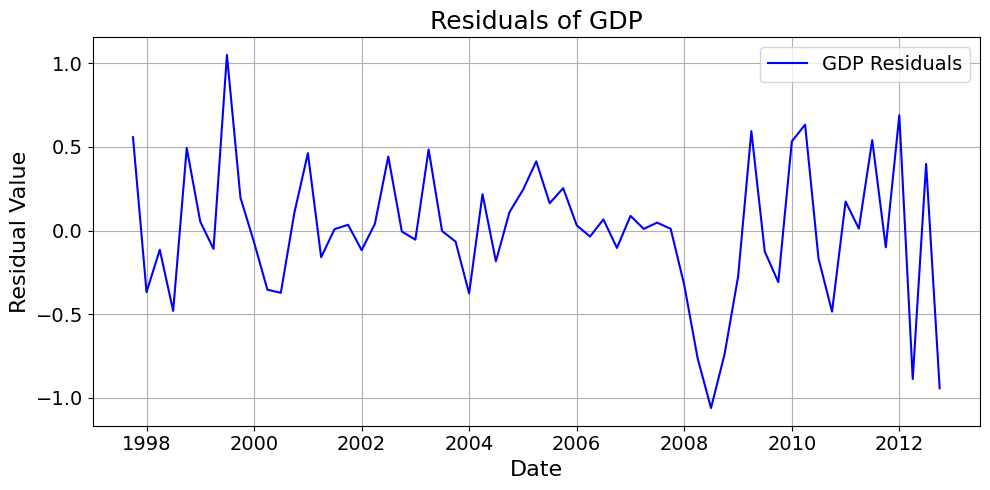

In [9]:
# Plot residuals for GDP
import matplotlib.pyplot as plt

residuals = model_fitted.resid
plt.figure(figsize=(10, 5))
plt.plot(residuals['GDP'], label='GDP Residuals', color='blue')
plt.title("Residuals of GDP", fontsize=18)
plt.xlabel("Date", fontsize=16)
plt.ylabel("Residual Value", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()





<Figure size 800x600 with 0 Axes>

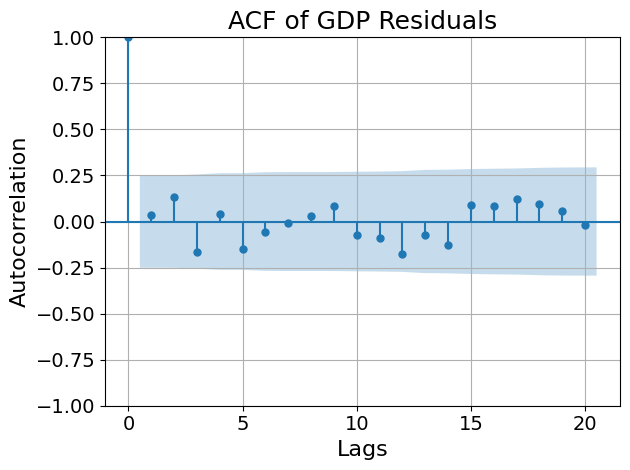

In [10]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plot_acf(residuals['GDP'], lags=20)
plt.title('ACF of GDP Residuals', fontsize=18)
plt.xlabel('Lags', fontsize=16)
plt.ylabel('Autocorrelation', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.grid(True)
plt.show()

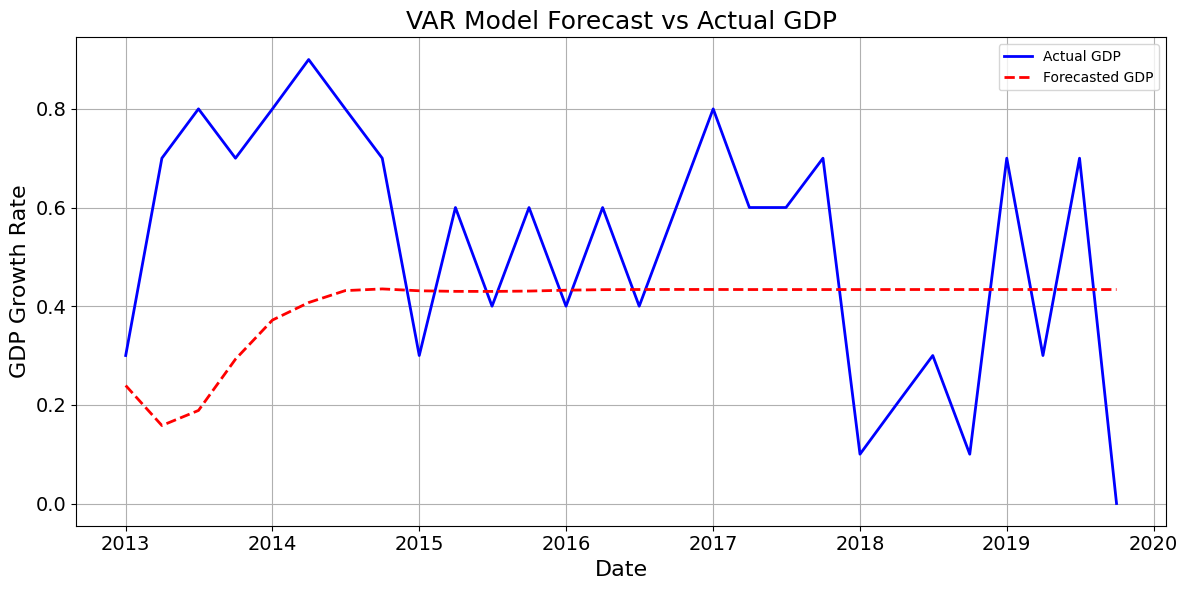

In [11]:
import matplotlib.pyplot as plt

actual_gdp = test['GDP']
predicted_gdp = forecast_df['GDP']

# Plot
plt.figure(figsize=(12, 6))
plt.plot(actual_gdp.index, actual_gdp.values, label='Actual GDP', linewidth=2, color='blue')
plt.plot(predicted_gdp.index, predicted_gdp.values, label='Forecasted GDP', linewidth=2, linestyle='--', color='red')
plt.title('VAR Model Forecast vs Actual GDP', fontsize=18)
plt.xlabel('Date', fontsize=16)
plt.ylabel('GDP Growth Rate', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig("var_forecast_vs_actual.png")
plt.show()


In [12]:
# Save results for comparison
var_forecast_df = pd.DataFrame({
    'Date': actual_gdp.index,
    'Actual_GDP': actual_gdp.values,
    'VAR_Forecast': predicted_gdp.values
})

# Save to CSV
#var_forecast_df.to_csv('var_forecast_results.csv', index=False)
